Bibliotecas necessárias.

In [1]:
# Instalar ou atualizar biblioteca necessária.
!pip install -q -U datasets huggingface_hub openai

# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from google import genai
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset
from openai import OpenAI

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.9 MB/s eta 0:00:00


Funções que povoam os Dataframes com as questões e respostas disponíveis no github.

In [2]:
# Resgata o segredo cadastrado com o nome para o hugging face
def logon_hugging_face(hugging_api_key):
  try:
    # Recuperar valor da chave criada no huggin face e cadastrada no Secrets do Google Colab.
    hf_token = userdata.get(hugging_api_key)
    # Realiza o login no Hugging Face
    login(token=hf_token)
  except Exception as e:
    print(f"Erro ao recuperar token: {e}")

# Povoar dataframe de questões do huggin face.
def load_questions(dataset_id):
  # Carrega o dataset (geralmente ele vem dividido em 'train', 'test', etc.)
  ds = load_dataset(dataset_id)

  # Converte uma partição específica 'train' para um dataframe.
  df = pd.DataFrame(ds['train'])

  # Inserir uma coluna para enumerar as questões, com contagem a partir do número 1, uma vez que a contagem de linhas do python é a partir do 0.
  df.insert(0, 'num', range(1, len(df)+1))

  # retorno da Dataframe.
  return df

# Dataframe com um subconjunto das perguntas e linhas guias.
# O índice do Dataframe começa do 0 (zero), portanto, a linha 1 é a 0, a 2 é a 1, etc.
# iloc seleciona um intervalo fechado à esquerda e aberto à direita
def load_my_close_questions(df_close_questions, question_min, question_max):
  # Remover 1 und dando o descontando, uma vez que o valor passado é o número da questão para o ser humano
  # e não a contagem do python.
  question_min -= 1
  df = df_close_questions.iloc[question_min:question_max].copy()
  return df

# Função para submeter uma questão à IA.
def question_submit(client_ai, model_id, question, question_type, alternatives):
    prompt_usuario = f"""
    Pessoa:
    Atue como um specialista Jurídico. Analise a questão da OAB abaixo:

    tipo_de_questao: {question_type}
    Questão: {question}
    Alternativas: {alternatives}

    Tarefas:
    1. Responda a questão escolhendo a letra correta (A, B, C ou D).
    2. Classifique a área de direito, com base na informação tipo_de_questao que pode está em inglês,
       e se for preciso traduza-a, para classificar a área.

    Responda no formato JSON somente com os dados que seguem:
    {{
      "resposta": "LETRA",
      "area": "NOME_DA_AREA"
    }}
    """

    # Check if the client is an OpenAI-compatible client (like from openai library, Groq, OpenRouter)
    if isinstance(client_ai, OpenAI):
      chat = client_ai.chat.completions.create(
          messages=[{"role": "user", "content": prompt_usuario}],
          model=model_id,
          response_format={"type": "json_object"}
      )
      return json.loads(chat.choices[0].message.content)
    # Check if the client is a Google Generative AI client
    elif isinstance(client_ai, genai.Client):
      response = client_ai.models.generate_content(
        model=model_id,
        contents=prompt_usuario,
        config=
          {
            "temperature": 0.1,  # Conservador.
            "max_output_tokens": 1024
          }
      )
      # The prompt asks for JSON, so we expect response.text to be a JSON string
      # We need to extract the text content correctly from the response object
      response_text = response.candidates[0].content.parts[0].text

      # Use regex for robust JSON extraction
      # This regex attempts to find either a JSON object within a markdown block (```json...```)
      # or a standalone JSON object.
      # The `re.DOTALL` flag allows '.' to match newline characters.
      json_match = re.search(r"```json\s*(\{[\s\S]*?\})\s*```|(\{[\s\S]*\})", response_text, re.DOTALL)

      json_string = None
      if json_match:
          # If the first group (markdown block) matched, use it. Otherwise, use the second group (standalone JSON).
          if json_match.group(1):
              json_string = json_match.group(1)
          elif json_match.group(2):
              json_string = json_match.group(2)

      if json_string:
          return json.loads(json_string)
      else:
          raise ValueError(f"Não foi possível extrair um JSON válido da resposta do modelo: {response_text}")
    else:
      raise ValueError("Unsupported AI client type provided.")

# Comparar resposta com gabarito.
def compare_answers(response, answer_key):
  if response == answer_key:
    return 'Certo'
  else:
    return 'Errado'

Dataset do hugging face

In [3]:
# Chave salva no Secrets do Google Colab.
hugging_api_key = 'hugging_colab'
logon_hugging_face(hugging_api_key)

# Meu sub-grupo de questões e respostas.
# Subconjunto das questões: 319 a 424.
question_min = 319
question_max = 424

# Povoar dataframe de questões do huggin face.
dataset_id = 'eduagarcia/oab_exams'
df_close_questions = load_questions(dataset_id)

# Criar um dataset com meu subconjunto de questões.
df_my_close_questions = load_my_close_questions(df_close_questions, question_min, question_max)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/649 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2210 [00:00<?, ? examples/s]

Usar o gemini 3.1 flash para responder.

In [7]:
import time

def client_ai_instance(name_api_key):
  # Recuperar a chave da API de forma segura, armazenada no Secrets do Google Colab.
  # O uso do Secrets é uma alternativa para que chave de API não fique exposta no código.
  # Tal chave previamente criada no previamente na pltaforma da IA aqui utilizada.
  # Observação: o nome da chave definido precisa ser o mesmo inclusive com diferenciação de letra maiúscula e minúscula.
  api_key = userdata.get(name_api_key)
  client_ai = None

  # Verificar se foi o groq ou google.
  if name_api_key == 'groq_api_key':
    client_ai = OpenAI(
      base_url="https://api.groq.com/openai/v1",
      api_key=api_key
  )
  elif name_api_key == 'oprouter_api_key':
    client_ai = OpenAI(
      base_url="https://openrouter.ai/api/v1/",
      api_key=api_key
    )
  elif name_api_key == 'google_api_key':
    client_ai = genai.Client(api_key=api_key)
  else:
    print('chave não encontrada')
  return client_ai

# O modelo escolhi do para rodar é o Gemini da Google em nuvém preview de 2026.
model_id = 'llama-3.3-70b-versatile'
client_ai = client_ai_instance('groq_api_key')

for index, row in df_my_close_questions.iterrows():
    # preenchimento dos parâmetros da pergunta, com base na linha corrente.
    question = row['question']
    question_type = row['question_type']
    alternatives = " | ".join(row['choices']['text'])
    answer_key = row['answerKey']
    response = question_submit(client_ai, model_id, question, question_type, alternatives)
    time.sleep(5)
    response_ai = response.get("resposta")
    # Comparar com o gabarito
    status = compare_answers(response_ai, answer_key)

    # Alterar diretamente no Dataframe
    df_my_close_questions.loc[index, 'response_ai'] = response_ai
    df_my_close_questions.loc[index, 'status'] = status


In [9]:
correct_answers = df_my_close_questions[df_my_close_questions['status'] == 'Certo'].shape[0]
total_questions = df_my_close_questions.shape[0]

if total_questions > 0:
    accuracy_percentage = (correct_answers / total_questions) * 100
    print(f"Percentual de acertos da IA: {accuracy_percentage:.2f}%")
else:
    print("Não há questões no DataFrame para calcular a precisão.")

Percentual de acertos da IA: 58.49%


In [18]:
import io
import base64
import matplotlib.pyplot as plt
import seaborn as sns

def plot_accuracy():
  # Create a DataFrame for plotting
  plot_data = pd.DataFrame({
      'Metric': ['Acurácia'],
      'Value': [accuracy_percentage]
  })

  plt.figure(figsize=(6, 4))
  sns.barplot(x='Metric', y='Value', data=plot_data, palette='viridis', hue='Metric', legend=False)
  plt.ylim(0, 100) # Percentage from 0 to 100
  plt.title(f'Total de Perguntas: {total_questions}')
  plt.ylabel('Percentagem (%)')
  plt.xlabel('') # No label needed for a single bar
  plt.text(x=0, y=accuracy_percentage + 2, s=f'{accuracy_percentage:.2f}%', ha='center', va='bottom', fontsize=12)

  # Save plot to a BytesIO object and encode to base64
  buffer = io.BytesIO()
  plt.savefig(buffer, format='png', bbox_inches='tight')
  buffer.seek(0)
  image_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
  plt.close() # Close the plot to prevent it from displaying twice
  return image_base64

In [17]:
# Exportar os dados processados até aqui em .jsonl para ocasião de uso posterior.
def ExportDataFrameToJSONL(df_my_close_questions):
  from google.colab import drive

  # 1. Mount Google Drive
  drive.mount('/content/drive')

  # 2. Define the path for the .jsonl file in Google Drive
  output_path = '/content/drive/My Drive/df_my_close_questions.jsonl'

  # 3. Export the DataFrame to .jsonl format
  df_my_close_questions.to_json(output_path, orient='records', lines=True)

  print(f"DataFrame exportado com sucesso para: {output_path}")

# Descomntar a linha abaixo e executar sobre demanda.
#ExportDataFrameToJSONL(df_my_close_questions)

Questão,Enunciado,Gabarito,IA,Situação
319,Em relação ao controle de constitucional ...,C,C,Certo
320,As alternativas a seguir apontam diferen ...,A,C,Errado
321,A respeito da distribuição de competênci ...,B,A,Errado
322,Os direitos políticos não podem ser cass ...,D,B,Errado
323,Considere a hipótese de Deputado Federal ...,A,B,Errado
324,"Washington, adolescente com 14 (quatorze ...",C,C,Certo
325,No tocante às normas contidas no Estatut ...,A,B,Errado
326,"Em âmbito federal, o direito de a Admini ...",D,B,Errado
327,A qualificação como Organizações da Soci ...,A,A,Certo
328,O contrato de prestação de serviços de q ...,C,C,Certo

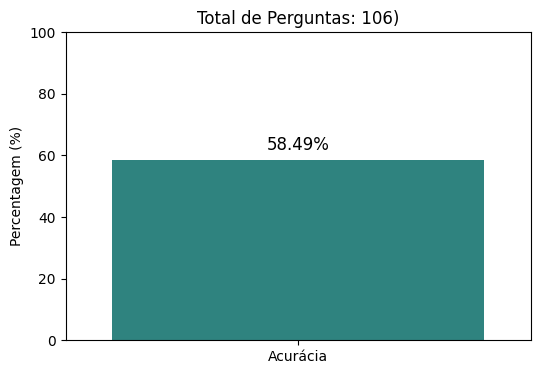

In [61]:
from IPython.display import HTML
from datetime import date

# Get today's date
today_date = date.today().strftime('%d/%m/%Y')

# Generate the accuracy plot as a base64 image
accuracy_plot_base64 = plot_accuracy()

# Function to generate HTML table from df_my_close_questions
def generate_results_table_html(df):
    # Select columns *including* 'num' as a regular column
    df_display = df[['num', 'question', 'answerKey', 'response_ai', 'status']].copy()

    # Rename columns for display
    df_display.rename(columns={
        'num': 'Questão',
        'question': 'Enunciado',
        'answerKey': 'Gabarito',
        'response_ai': 'IA',
        'status': 'Situação'
    }, inplace=True)

    # Shorten question text
    df_display['Enunciado'] = df_display['Enunciado'].apply(lambda x: x[:40] + ' ...' if len(x) > 40 else x)

    # Use Styler to apply CSS to cells and headers
    styler = df_display.style.set_properties(**{'text-align': 'left'})
    # Apply background color to headers using Styler's set_table_styles
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#ADD8E6'), ('font-weight', 'bold')]}
    ], overwrite=False)

    # Explicitly hide the index column
    styler = styler.hide(axis="index")

    # Convert DataFrame Styler to HTML, without showing the DataFrame's internal index
    table_html = styler.to_html(index=False,  # Explicitly set index=False, though hide(axis="index") should handle it
                                classes='dataframe table table-striped table-hover',
                                border=0)
    return table_html

# Generate the results table HTML
results_table_html = generate_results_table_html(df_my_close_questions)

html_report = f"""
    <html>
    <head>
        <style>
            body {{ font-family: sans-serif; line-height: 1.6; color: #333; margin: 20px; background-color: #f8f8f8; }}
            .container {{ max-width: 800px; margin: auto; background: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 0 15px rgba(0,0,0,0.1); }}
            h1 {{ color: #0056b3; border-bottom: 2px solid #0056b3; padding-bottom: 10px; margin-bottom: 20px; text-align: center; }}
            h2 {{ color: #0056b3; margin-top: 30px; border-bottom: 1px solid #eee; padding-bottom: 5px; }}
            ul {{ list-style-type: disc; margin-left: 20px; padding-left: 0; }}
            li {{ margin-bottom: 10px; }}
            strong {{ color: #0056b3; }}
            .accuracy-box {{ background-color: #e6f7ff; border: 1px solid #b3e0ff; padding: 15px; border-radius: 5px; text-align: center; margin-top: 20px; font-size: 1.2em; }}
            .accuracy-value {{ font-size: 1.8em; font-weight: bold; color: #007bff; }}
            .plot-container {{ text-align: center; margin-top: 20px; }}
            .plot-container img {{ max-width: 100%; height: auto; border: 1px solid #ddd; border-radius: 5px; padding: 5px; background: #fff; }}
            .info-block {{ background-color: #f0f8ff; border: 1px solid #cceeff; padding: 15px; border-radius: 5px; margin-top: 20px; margin-bottom: 20px; font-size: 0.95em; line-height: 1.5; }}
            .info-block p {{ margin: 5px 0; }}
            /* Table Styling */
            .dataframe {{ border-collapse: collapse; margin-top: 20px; }}
            .dataframe th, .dataframe td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
            .dataframe tbody tr:nth-child(odd) {{ background-color: #ffffff; }} /* White for odd rows */
            .dataframe tbody tr:nth-child(even) {{ background-color: #f9f9f9; }} /* Light gray for even rows */
            .dataframe tr:hover {{ background-color: #f1f1f1; }}
            .dataframe th:first-child, .dataframe td:first-child {{ display: none; }} /* Hide the first column */
        </style>
    </head>
    <body>
        <div class="container">
            <h1>Avaliação de respostas de questões de multipla escolha da OAB por um modelo de IA</h1>

            <div class="info-block">
                <p><strong>Aluno:</strong> Eduardo Henrique</p>
                <p><strong>Data de realização de teste:</strong> {today_date}</p>
                <p><strong>Código fonte:</strong> <a href="https://github.com/eduoududu/juridico" target="_blank">https://github.com/eduoududu/juridico</a></p>
            </div>

            <h2>Etapas Realizadas:</h2>
            <ul>
                <li><strong>Importação do Conjunto de Dados:</strong> O projeto iniciou com a importação de um conjunto de dados do Hugging Face.</li>
                <li><strong>Fonte dos Dados:</strong> Os dados foram obtidos de <code>{dataset_id}</code>, que consiste em um conjunto de provas de múltipla escolha da OAB, incluindo perguntas, opções de resposta (A, B, C, D) e o gabarito oficial de cada questão.</li>
                <li><strong>Seleção de Subconjunto:</strong> Foi selecionado um subconjunto específico de {total_questions} questões, abrangendo do número 319 ao 424, para a realização da análise.</li>
                <li><strong>Submissão à IA:</strong> O subconjunto de {total_questions} questões foi submetido ao modelo de LLM <strong>{model_id}</strong> (um modelo Llama 3 de 70 bilhões de parâmetros). A temperatura do modelo foi configurada para 0.1, visando um comportamento mais conservador e respostas menos criativas.</li>
                <li><strong>Armazenamento e Comparação:</strong> As respostas geradas pela IA foram armazenadas no mesmo DataFrame que contém as perguntas, opções e gabarito. Em seguida, essas respostas foram comparadas com o gabarito para calcular a taxa de acerto do modelo.</li>
            </ul>

            <h2>Resultados Encontrados:</h2>
            <div class="accuracy-box">
                <p>O percentual de acertos da IA para o subconjunto de questões analisado foi de:</p>
                <p class="accuracy-value">{accuracy_percentage:.2f}%</p>
            </div>
            <div class="plot-container">
                <h3>Gráfico de Acurácia Geral</h3>
                <img src="data:image/png;base64,{accuracy_plot_base64}" alt="Gráfico de Acurácia da IA">
            </div>
            <h2>Detalhes das Questões e Respostas</h2>
            {results_table_html}
        </div>
    </body>
    </html>
"""

HTML(html_report)